## Crank-Nicolson con coeficiente de difusión variable $k(x,t)$

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maurimendiluce/AN2026/blob/main/diferencias_finitas/clase_4_bis.ipynb)

Consideramos el problema

$$
\begin{aligned}
u_t &= k(x,t)\, u_{xx}, \qquad 0<x<1,\ \ 0<t\le T,\\[2pt]
u(0,t) &= u(1,t) = 0,\\[2pt]
u(x,0) &= u_0(x).
\end{aligned}
$$

El objetivo de esta notebook es doble:

1. Comparar dos formas de discretizar $k$ dentro de cada paso de Crank-Nicolson:
   - evaluarlo en $(x_j, t_n)$ (el instante "de la izquierda"), o
   - evaluarlo en $(x_j, t_n+\tfrac{\Delta t}{2})$ (el punto medio temporal),

   y mostrar numéricamente que la segunda opción recupera el orden 2 en tiempo, mientras que la primera lo degrada a orden 1.

2. Mostrar qué pasa si $k$ **no** es una función positiva: el problema pierde la estabilidad

### Discretización espacial

Malla $x_j = jh$, $j=0,\dots,M$, con $h=1/M$; tiempos $t_n = n\Delta t$, con $\Delta t = T/N$.

Como siempre, aproximamos

$$
u_{xx}(x_j,t) \approx (D_2 U)_j := \frac{U_{j-1}-2U_j+U_{j+1}}{h^2}.
$$

### Esquema de Crank-Nicolson centrado en $t_{n+1/2}$

Crank-Nicolson aproxima la EDP evaluada en el punto medio temporal $t_{n+1/2}=t_n+\Delta t/2$:

$$
u_t(x_j,t_{n+1/2}) \approx \frac{U_j^{n+1}-U_j^n}{\Delta t} \qquad (\text{orden } \Delta t^2),
$$

$$
u_{xx}(x_j,t_{n+1/2}) \approx \frac{1}{2}\Big[(D_2U^{n+1})_j + (D_2U^n)_j\Big] \qquad (\text{orden } \Delta t^2).
$$

Como el coeficiente que multiplica a $u_{xx}$ en la EDP también está evaluado en $t_{n+1/2}$, lo natural —y lo que preserva el orden 2— es usar $k^\star_j = k(x_j,t_{n+1/2})$ en **ambos** lados:

$$
\frac{U_j^{n+1}-U_j^n}{\Delta t} = \frac{k^\star_j}{2}\Big[(D_2U^{n+1})_j + (D_2U^n)_j\Big].
$$

Definiendo $r_j = \dfrac{k^\star_j\,\Delta t}{2h^2}$, esto es el sistema tridiagonal:

$$
-r_j U_{j-1}^{n+1} + (1+2r_j)U_j^{n+1} - r_j U_{j+1}^{n+1} = r_j U_{j-1}^{n} + (1-2r_j)U_j^{n} + r_j U_{j+1}^{n}.
$$

### Evaluar $k$ en $t_n$

Si en cambio ponemos $k^\star_j = k(x_j,t_n)$ (lo primero que a uno se le ocurriría, por analogía con el caso $k$ constante), el sistema tridiagonal es idéntico en forma, sólo cambian los $r_j$. Pero el análisis de orden ya no da lo mismo.

Con $k$ evaluado en el punto medio, la parte espacial promediada ya es $u_{xx}(t_{n+1/2})+O(\Delta t^2)$, así que el truncado del esquema es

$$
\big[k(x_j,t_{n+1/2}) - k^\star_j\big]\, u_{xx}(x_j,t_{n+1/2}) + O(\Delta t^2) + O(h^2).
$$

- Si $k^\star_j = k(x_j,t_{n+1/2})$ (punto medio), el corchete es $O(\Delta t^2)$ → error local (sin escalar por $\Delta t$) $O(\Delta t^3)$ → **orden global 2**, el CN habitual.
- Si $k^\star_j = k(x_j,t_n)$, Taylor da $k(x_j,t_{n+1/2}) - k(x_j,t_n) = \tfrac{\Delta t}{2}k_t(x_j,t_{n+1/2}) + O(\Delta t^2)$, así que el corchete es $O(\Delta t)$ (a menos que $k_t\equiv 0$) → error local $O(\Delta t^2)$ → **orden global 1**.

Es decir: la pérdida de orden es puramente temporal, y sólo aparece si $k$ depende efectivamente de $t$. Vamos a verificarlo numéricamente.

In [1]:
using LinearAlgebra
using Printf
using Plots

In [ ]:
function crank_nicolson_variable_k(k::Function, u0::Function, M::Int, N::Int, T::Float64;
                                    k_eval::Symbol=:midpoint)
    @assert k_eval in (:midpoint, :left) "k_eval debe ser :midpoint o :left"

    h  = 1.0 / M
    dt = T / N
    x  = collect(range(0.0, 1.0, length=M+1))
    t  = collect(range(0.0, T, length=N+1))

    U = zeros(M+1, N+1)
    U[:, 1]   = u0.(x)
    U[1, :]   .= 0.0   # u(0,t) = 0
    U[end, :] .= 0.0   # u(1,t) = 0

    for n in 1:N
        tn    = t[n]
        teval = k_eval == :midpoint ? tn + dt/2 : tn

        # rⱼ para los M-1 puntos interiores x₁,...,x_{M-1} (índices 2:M en Julia)
        r = [k(x[j], teval) * dt / (2h^2) for j in 2:M]

        d  = 1.0 .+ 2.0 .* r
        dl = -r[2:end]      # subdiagonal
        du = -r[1:end-1]    # superdiagonal
        A  = Tridiagonal(dl, d, du)

        Un  = @view U[:, n]
        rhs = [r[idx]*Un[j-1] + (1 - 2r[idx])*Un[j] + r[idx]*Un[j+1]
               for (idx, j) in enumerate(2:M)]

        U[2:M, n+1] = A \ rhs
    end

    return U, x, t
end

crank_nicolson_variable_k

### Prueba con solución exacta

Tomamos

$$
k(x,t) = 2+\sin(t) \quad (>0 \text{ siempre}),
$$

que depende sólo de $t$. Con el cambio de variable temporal $\tau(t)=\displaystyle\int_0^t k(s)\,ds$, la ecuación $u_t = k(t)u_{xx}$ se reduce a la ecuación del calor estándar $v_\tau = v_{xx}$ en la variable $v(x,\tau)=u(x,t)$ (regla de la cadena: $u_t = \tau'(t)\,v_\tau = k(t)v_\tau$). Entonces, si $v(x,\tau)=\sin(\pi x)e^{-\pi^2\tau}$ (solución exacta del calor estándar con $v(x,0)=\sin(\pi x)$), la solución exacta de nuestro problema es

$$
u(x,t) = \sin(\pi x)\, e^{-\pi^2 \tau(t)}, \qquad
\tau(t) = \int_0^t (2+\sin s)\,ds = 2t + 1 - \cos t.
$$

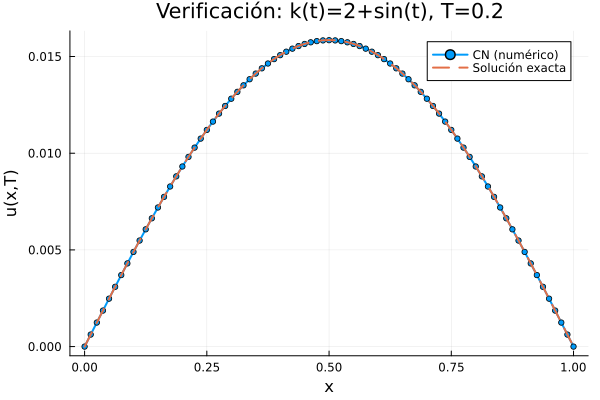

In [3]:
k_test(x, t)       = 2 + sin(t)
τ_test(t)          = 2t + 1 - cos(t)
u_exact_test(x, t) = sin(π*x) * exp(-π^2 * τ_test(t))
u0_test(x)         = sin(π*x)

# chequeo visual rápido
M, N, T = 80, 80, 0.2
U, x, t = crank_nicolson_variable_k(k_test, u0_test, M, N, T; k_eval=:midpoint)

plot(x, U[:, end], label="CN (numérico)", lw=2, marker=:circle, ms=3)
plot!(x, u_exact_test.(x, T), label="Solución exacta", lw=2, ls=:dash)
xlabel!("x"); ylabel!("u(x,T)")
title!("Verificación: k(t)=2+sin(t), T=$T")

### Orden de convergencia temporal: `:midpoint` vs `:left`

Para aislar el error *temporal*, fijamos una malla espacial muy fina (de modo que el error $O(h^2)$ quede muy por debajo del error temporal que queremos medir) y refinamos sólo $\Delta t$, duplicando $N$ en cada paso. El orden local se estima como,

$$
\alpha \approx \frac{\log(E_i/E_{i+1})}{\log(\Delta t_i/\Delta t_{i+1})} = \frac{\log(E_i/E_{i+1})}{\log 2},
$$

siguiendo la misma idea de pares consecutivos (en vez de un ajuste global) que usamos en las notebooks anteriores: revela mejor si el error deja de bajar por redondeo de punto flotante.

In [ ]:
function orden_convergencia_temporal(k::Function, u0::Function, uex::Function,
                                      M::Int, T::Float64, Ns::Vector{Int}; k_eval::Symbol=:midpoint)
    errores = Float64[]
    for N in Ns
        U, x, t = crank_nicolson_variable_k(k, u0, M, N, T; k_eval=k_eval)
        e = maximum(abs.(U[:, end] .- uex.(x, T)))
        push!(errores, e)
    end

    println("k_eval = :$k_eval")
    @printf("%6s  %10s  %12s  %8s\n", "N", "Δt", "E∞", "orden α")
    for i in eachindex(Ns)
        dt = T / Ns[i]
        if i == 1
            @printf("%6d  %10.5f  %12.4e  %8s\n", Ns[i], dt, errores[i], "-")
        else
            α = log(errores[i-1]/errores[i]) / log(2)
            @printf("%6d  %10.5f  %12.4e  %8.3f\n", Ns[i], dt, errores[i], α)
        end
    end
    return errores
end

M_fino = 2000     # malla espacial fija y fina: el error espacial O(h²) no
                  # debe contaminar la medición del orden temporal
Ns = [10, 20, 40, 80, 160, 320, 640, 1280]

errores_mid = orden_convergencia_temporal(k_test, u0_test, u_exact_test, M_fino, T, Ns; k_eval=:midpoint)
println()
errores_left = orden_convergencia_temporal(k_test, u0_test, u_exact_test, M_fino, T, Ns; k_eval=:left)

k_eval = :midpoint
     N          Δt            E∞   orden p
    10     0.02000    9.3873e-04         -
    20     0.01000    2.3539e-04     1.996
    40     0.00500    5.8880e-05     1.999
    80     0.00250    1.4712e-05     2.001
   160     0.00125    3.6681e-06     2.004
   320     0.00063    9.0692e-07     2.016
   640     0.00031    2.1660e-07     2.066
  1280     0.00016    4.4020e-08     2.299

k_eval = :left
     N          Δt            E∞   orden p
    10     0.02000    6.2998e-04         -
    20     0.01000    7.9834e-05     2.980
    40     0.00500    1.8938e-05     2.076
    80     0.00250    2.4176e-05    -0.352
   160     0.00125    1.5767e-05     0.617
   320     0.00063    8.8082e-06     0.840
   640     0.00031    4.6402e-06     0.925
  1280     0.00016    2.3842e-06     0.961


8-element Vector{Float64}:
 0.0006299763806697379
 7.983355674656342e-5
 1.8937757282570106e-5
 2.417613537806715e-5
 1.5767364759319835e-5
 8.808176511949928e-6
 4.640222662073007e-6
 2.3842026751555445e-6

**Qué esperar de la tabla anterior:**

- Con `:midpoint`, el orden estimado debería estabilizarse cerca de $\alpha\approx 2$ en todo el rango de $N$, hasta que $\Delta t$ es tan chico que el error toca el piso de precisión de punto flotante (ahí el orden estimado se vuelve errático — no es un fallo del método, es redondeo).
- Con `:left`, para $N$ chico el orden estimado puede verse engañosamente alto o incluso negativo por un tramo; recién para $N$ suficientemente grande el orden converge establemente a $\alpha\approx 1$. Esto es en sí mismo una lección útil: **estimar el orden con sólo dos o tres refinamientos consecutivos puede ser engañoso** si no se está ya en el régimen asintótico.

### $k$ no positiva

Para $k$ constante, el factor de amplificación de Crank-Nicolson para el modo de Fourier 

$$
\lambda = \frac{1-2s}{1+2s}, \qquad s = r\sin^2\!\Big(\frac{\xi h}{2}\Big), \qquad r = \frac{k\Delta t}{h^2}.
$$

- Si $k>0$ (r>0), entonces $s\ge 0$ y $|\lambda|\le 1$ para **todo** $\xi$: CN es incondicionalmente estable, cualquiera sea $\Delta t$.
- Si $k<0$ (r<0), entonces $s<0$ y se puede verificar que $|\lambda|>1$: CN amplifica todas las frecuencias, y las más altas (las que admite una malla más fina) se amplifican más.

### $k(x)=\cos(2\pi x)$, cambia de signo en $(0,1)$

$k$ es negativa en parte del dominio y positiva en el resto. Con un dato inicial genérico (no un modo propio puro) las frecuencias más altas son las que más rápido se amplifican. A diferencia de un problema bien puesto, **refinar la malla no mejora la solución: la empeora**, porque una malla más fina admite frecuencias más altas y más inestables. 

In [6]:
k_sign(x, t) = cos(2π*x)
u0_bump(x)   = exp(-100*(x-0.5)^2) * sin(π*x)

println("  M     max|U(x,T)|   (T = 0.01, dato inicial con max|u0| = 1)")
for M in [20, 40, 80, 160]
    U, x, t = crank_nicolson_variable_k(k_sign, u0_bump, M, 40, 0.01)
    @printf("%4d     %.4e\n", M, maximum(abs.(U[:,end])))
end

  M     max|U(x,T)|   (T = 0.01, dato inicial con max|u0| = 1)
  20     1.5487e+04
  40     8.5842e+27
  80     2.9657e+71
 160     1.3574e+84


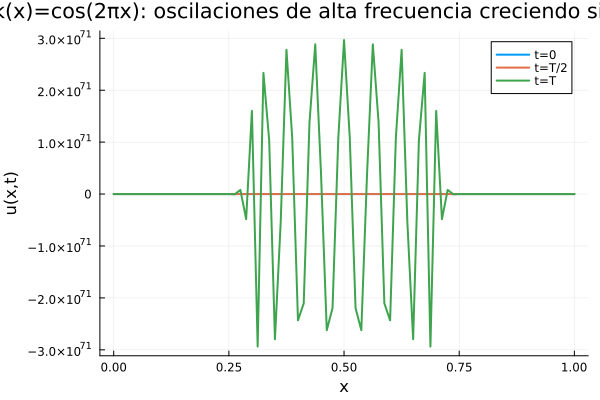

In [7]:
M, N, T = 80, 40, 0.01
U, x, t = crank_nicolson_variable_k(k_sign, u0_bump, M, N, T)

plot(x, U[:, 1],           label="t=0",   lw=2)
plot!(x, U[:, div(N,2)+1], label="t=T/2", lw=2)
plot!(x, U[:, end],        label="t=T",   lw=2)
xlabel!("x"); ylabel!("u(x,t)")
title!("k(x)=cos(2πx): oscilaciones de alta frecuencia creciendo sin control")

### Conclusiones

1. **Orden temporal de CN con $k$ variable en el tiempo:** evaluar $k$ en el punto medio $t_n+\Delta t/2$ preserva el orden 2 característico de Crank-Nicolson; evaluarlo en $t_n$ lo degrada a orden 1, con la salvedad de que un test de orden con pocos refinamientos puede verse engañosamente bueno (o hasta negativo) antes de entrar al régimen asintótico.
2. **Positividad de $k$ no es un tecnicismo:** cuando $k$ cambia de signo (o es negativa), el problema continuo deja de ser parabólico bien puesto. Crank-Nicolson —o cualquier otro esquema— reproduce fielmente esa inestabilidad, y el crecimiento se vuelve *peor*, no mejor, al refinar la malla. Eso es exactamente lo opuesto al comportamiento esperado de un método convergente, y es la señal de que el problema en sí, no el esquema, es el problema.